<a href="https://colab.research.google.com/github/flatironinstitute/2026-flatiron-cmb-summer-school/blob/main/notebooks/CMB_School_ymap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Tutorial on tSZ Compton-y ILC map: WebSky Simulations and ACT DR6 Cross-Correlation**


This notebook, featured in the 2026 Flatiron Institute CMB Summer School, is adapted from CMB_School_Part_11_foregrounds_and_ILC.ipynb https://github.com/jeffmcm1977/CMBAnalysis_SummerSchool (credits: Jeff McMahon, Renee Hlozek, Will Coulton) and ACT_DR6_ymap_CIB.ipynb from https://github.com/ACTCollaboration/DR6_Notebooks/ (credits: Ola Kusiak and ACT collaboration).

**Load the necessary packages**

In particular, we will need `pymaster`, which is a bit more complicated to install than the other packages because it requires several C libraries (`gsl`, `fftw3`, `cfitsio`, `chealpix`). (We recommend running the cells one-by-one!)

In [ ]:
# Install libraries
%%capture
!apt-get update
!apt-get install -y automake autoconf libtool libgsl-dev libfftw3-dev libcfitsio-dev libchealpix-dev

In [ ]:
# %%Install numpy and pymaster
!C_INCLUDE_PATH=/usr/include/chealpix pip install 'pymaster==1.6'

In [ ]:
# Install pixell, healpy, and camb
%%capture
!pip install pixell healpy camb

In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import os, subprocess
from pixell import enmap, enplot, utils, curvedsky
import pymaster as nmt
import camb

def eshow(x,**kwargs):
    ''' Define a function to help us plot the maps neatly '''
    plots = enplot.get_plots(x, **kwargs)
    enplot.show(plots, method = "ipython")

# The thermal Sunyaev-Zel'dovich (tSZ) effect

The thermal Sunyaev-Zel'dovich effect arises when CMB photons inverse-Compton scatter off hot, energetic electrons, most notably the ionized gas in galaxy clusters and the warm intergalactic medium. This scattering distorts the CMB blackbody spectrum, producing a frequency-dependent decrement below $\sim$ 220 GHz and an increment above it (in the non-relativistic limit).


The effect is conventionally parametrized through the dimensionless Compton-$y$ parameter,

$y(\hat{n}) = \frac{\sigma_T}{m_e c^2} \int_{\rm{los}} P_e \, dl$


where $\sigma_T$ is the Thomson cross-section, $P_e = n_e k_B T_e$
is the electron pressure, and the integral is along the line of sight (LOS). Since $y$ traces the integrated electron pressure, it is sensitive to the hot gas in massive halos and is one of the cleanest probes of the baryonic content of large-scale structure.


Because the tSZ spectral signature is known, Compton-$y$
maps can be reconstructed from multi-frequency CMB data using component-separation techniques, such as the  Internal Linear Combination (ILC) method (more details below). However, this separation is imperfect: other sky signals with similar spatial scales but different frequency dependence, most importantly the CIB, can leak into the reconstructed $y$-map, which is the systematic this notebook investigates.

# ILC tutorial on WebSky Simulations

We will start by learning about the Internal Linear Combination (ILC) method, and applying it to simulated y-maps from the **WebSky** simulation suite (Stein et al. 2020), before moving on to the real ACT DR6 Compton-$y$ map later in this notebook.

WebSky provides a known "ground truth" Compton-$y$ map
(`tsz_2048.fits`, a HEALPix map at nside=2048) built from an N-body lightcone using the Battaglia et al. (2012) pressure profile model.

## 1. Download the WebSky y map

Download the `tsz_2048.fits` (384 MB)  Websky map, if not already present.

In [ ]:
WEBSKY_URL = "https://mocks.cita.utoronto.ca/data/websky/v0.0/tsz_2048.fits"
WEBSKY_PATH = "tsz_2048.fits"

if not os.path.exists(WEBSKY_PATH):
    print(f"downloading {WEBSKY_URL} ...")
    subprocess.run(["wget", "-c", "-O", WEBSKY_PATH, WEBSKY_URL], check=True)

Let's look at the Websky $y$-map more closely.

In [ ]:
y_map = hp.read_map(WEBSKY_PATH)
nside = hp.get_nside(y_map)
npix = hp.nside2npix(nside)

print(f"loaded WebSky y map: nside={nside}")

In [ ]:
hp.mollview(y_map, title=f'WebSky Compton-y (full sky, nside={nside})',
            cmap='inferno', min=0, max=5e-6, unit='y')
plt.show()

When you visualize the Websky $y$-map above, you can clearly see many galaxy clusters by eye.
This is because the tSZ signal scales steeply with halo mass, $Y \propto M^{5/3}$, so a small number of massive clusters dominate the total signal and stand out as bright, compact peaks above the much fainter diffuse contribution from lower-mass halos and filaments.

> **Question**: can you explain why the tSZ effect scales roughly as $M^{5/3}$ ?

Let's inspect a small patch of the maps. Feel free to change `patch_lon`, `patch_lat` to look at other parts of the sky.

In [ ]:
patch_lon, patch_lat = 0.0, 50.0   # galactic coords, degrees -- arbitrary
patch_xsize = 200                  # pixels per side of the illustration patch
patch_reso = 1.5                   # arcmin/pixel for the illustration patch (~5 deg across)


def patch(m, **kw):
    """Cut a small patch out of a full-sky map, for plotting only."""
    return np.asarray(hp.gnomview(m, rot=(patch_lon, patch_lat), xsize=patch_xsize,
                                   reso=patch_reso, return_projected_map=True,
                                   no_plot=True, **kw))

plt.figure(figsize=(5,4.5))
plt.imshow(patch(y_map), cmap='inferno', origin='lower')
plt.colorbar(label='Compton-y')
plt.title(f'WebSky y, zoomed patch near (l,b)=({patch_lon:.0f},{patch_lat:.0f})')
plt.show()

## 2. Full-sky simulated maps, frequency scaling, beams, noise

We will now construct simplified multi-frequency sky maps containing three ingredients: a CMB
realisation, a tSZ signal (from the WebSky $y$-map), and white instrument noise.






First, we will turn the dimensionless WebSky Compton-$y$ map into something closer to what a real multi-frequency CMB experiment observes. At each frequency, the tSZ signal is

$$\Delta T_{\rm tSZ}(\nu) = g(\nu)\, y, \qquad g(\nu) = T_{\rm CMB}\left[x\coth(x/2) - 4\right], \qquad x = \frac{h\nu}{k_B T_{\rm CMB}},$$

i.e. the $y$ map scaled by the known tSZ spectral function $g(\nu)$.

We also need to include instrumental effects: white noise and beams. For the instrumental model we assume a Gaussian beam of width $\theta_{\rm FWHM}$ (convolved with both the CMB and tSZ maps) and white noise with amplitude $\Delta_T$ in units of
$\mu{\rm K}$-arcmin. The values below are broadly ACT-like, but feel free to experiment with the values here.

Below we define instrument specifications.

In [ ]:
#Instrument specifications
freqs = [90., 150., 220.]
beams_fwhm_arcmin = [2.2, 1.4, 1.0]
noise_uK_arcmin = [10., 8., 20.]

#constants
TCMB = 2.7255e6  # uK
h = 6.626e-34
kB = 1.381e-23


# tSZ frequency-dependance
def g_nu(freq_GHz):
    x = h*(freq_GHz*1e9)/(kB*2.7255)
    return TCMB*(x/np.tanh(x/2.) - 4.)

# beam
def beam_bl(fwhm_arcmin, lmax):
    sigma = np.radians(fwhm_arcmin/60.)/np.sqrt(8*np.log(2))
    ell = np.arange(lmax+1)
    return np.exp(-0.5*ell*(ell+1)*sigma**2)


print("g(nu) [uK per unit y]:")
for f in freqs:
    print(f"  {f:6.0f} GHz : {g_nu(f):9.1f}")


> **Exercise:** Plot the frequency dependance of the tSZ effect.

In [ ]:
freqs_array = np.arange(30, 545, 1) # GHz

plt.figure(figsize=(6,4))
# plt.plot()

plt.axhline(0, color='k', lw=0.5)
plt.legend(); plt.title('tSZ frequency dependance')
plt.show()

To run the ILC, we also need the CMB power spectrum — both to draw a physically realistic CMB
realisation and to ensure the relative amplitude of CMB vs. tSZ vs. noise in our frequency maps
is correct. We compute $C_\ell^{TT}$ using **CAMB** for a fiducial Planck 2018 cosmology.

In [ ]:
lmax = 3000 #3*nside - 1
print(f"lmax = {lmax}")

#CAMB arguments
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.36, ombh2=0.02237, omch2=0.1200, mnu=0.06, omk=0, tau=0.0544)
pars.InitPower.set_params(As=2.100e-9, ns=0.9649)
pars.set_for_lmax(lmax, lens_potential_accuracy=1)
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', lmax=lmax)
Dl_cmb = powers['total'][:, 0]   # lensed TT, D_ell = ell(ell+1)C_ell/2pi, in uK^2


ell = np.arange(len(Dl_cmb))
Cl_cmb = np.zeros_like(Dl_cmb)
Cl_cmb[2:] = Dl_cmb[2:]*2*np.pi/(ell[2:]*(ell[2:]+1))

plt.figure(figsize=(6,4))
plt.loglog(ell[2:], ell[2:]*(ell[2:]+1)*Cl_cmb[2:]/(2*np.pi))
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$ [$\mu K^2$]')
plt.title('CAMB lensed CMB TT spectrum')
plt.show()

In [ ]:
# Gaussian realization of the CAMB power spectrum
cmb_map = hp.synfast(Cl_cmb, nside, lmax=lmax, new=True)
print(f"CMB map rms = {cmb_map.std():.1f} uK")

Now we add the same primary CMB realization at every frequency, convolve the combined sky with that channel's beam, and add white instrument noise. One could of course add more realism to our simulated sky — the kinetic SZ effect, the Cosmic Infrared Background, injected point sources, and so on — but this is enough to illustrate the ILC. These are the maps the ILC will actually operate on.

> **Exercise:** The cell below constructs the frequency maps. Try writing it from scratch:
starting from `cmb_alm` and `y_alm`, build `freq_maps` and `freq_maps_sz` for each channel. You will need to apply the beam, scale the $y$-map by
its frequency dependance, and add Gaussian white noise.


In [ ]:
cmb_alm = hp.map2alm(cmb_map, lmax=lmax)
y_alm   = hp.map2alm(y_map,   lmax=lmax)

rng = np.random.default_rng(1)

freq_maps = {}     # CMB + tSZ + noise (what a real instrument would see)
freq_maps_sz = {}  # tSZ + noise only (for illustrating the tSZ signal in isolation)

# your code goes here


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, f in zip(axes, freqs):
    # im = ax.imshow(patch(freq_maps[f]), cmap='RdBu_r', origin='lower', vmin=-300, vmax=300)
    ax.set_title(f'{f:.0f} GHz')
plt.suptitle('Frequency maps (CMB + tSZ + noise), zoomed patch')
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, f in zip(axes, freqs):
    # im = ax.imshow(patch(freq_maps_sz[f]), cmap='RdBu_r', origin='lower', vmin=-300, vmax=300)
    ax.set_title(f'{f:.0f} GHz')
plt.suptitle('Frequency maps (tSZ only), zoomed patch')
plt.tight_layout(); plt.show()

## 4. Full-sky harmonic ILC (preserving tSZ)

### The Internal Linear Combination idea

A multi-frequency CMB experiment observes a sky signal at each frequency $\nu$ that is a
superposition of several components — CMB, tSZ, CIB, noise, and so on. If we label the
observed map at frequency $\nu$ as $T_\nu$, and denote the (known) frequency dependence of
our target signal as $f(\nu)$, the ILC asks: what are the weights $w_\nu$ for which the linear combination

$$\widehat{s} = \sum_\nu w_\nu \, T_\nu$$

minimises the total variance of $\widehat{s}$, subject to an unbiased response to the target signal (here $y$)

$$\sum_\nu w_\nu f(\nu) = 1$$


The key insight is that *only* the spectral shape of the target need be known — the statistics of the CMB, noise, and other foregrounds are learned from the data themselves.

### Standard minimum-variance ILC

Working in harmonic space, at each multipole $\ell$ we have a vector of N frequency maps $\mathbf{T}_\ell = (T^\nu_{\ell m})_\nu = (T^{\nu_1}_{\ell m},\,\ldots,\,
T^{\nu_N}_{\ell m})^T$. The ILC solution follows from minimising the variance the maps

\begin{equation}
    \mathrm{Var}(\widehat{s}) = \mathbf{w}^T \mathbf{C}_\ell \mathbf{w}
\end{equation}

subject to $\mathbf{w}^T \mathbf{f} = 1$, where $\mathbf{f} = (f(\nu_1), \ldots,
f(\nu_N))^T$ is the spectral response vector. Using the Lagrange multiplier technique, we get:

\begin{equation}
    \boxed{\mathbf{w}_\ell = \frac{\mathbf{C}_\ell^{-1}\,\mathbf{f}}
                                   {\mathbf{f}^T\,\mathbf{C}_\ell^{-1}\,\mathbf{f}}}
\end{equation}

where $\mathbf{C}_\ell$ is the $N_\nu \times N_\nu$ empirical frequency--frequency
covariance at multipole $\ell$, with elements
$(\mathbf{C}_\ell)^{\nu\nu'} = \langle T^\nu_{\ell m} T^{\nu'*}_{\ell m}\rangle$.
For the tSZ effect the response vector is $f(\nu) = g(\nu)/T_{\rm CMB}$, the spectral
distortion function defined in Section 3.


### Constrained (deprojection) ILC extension


The basic ILC minimises variance without any explicit control over which foregrounds survive.
A natural generalisation ([Remazeilles et al. 2011](https://arxiv.org/abs/1103.1166)) adds further constraints to null specific
contaminants with known spectral shapes $\mathbf{f}_{\rm null}$:
\begin{equation}
\mathbf{w}^T \mathbf{f}_{\rm null} = 0
\end{equation}

The weights that obey both constraints are

\begin{equation}
    \mathbf{w}_\ell = \mathbf{e}^T
    \left(\mathbf{F}^T \mathbf{C}_\ell^{-1}\mathbf{F}\right)^{-1}\mathbf{C}_\ell^{-1}\mathbf{F},
    \qquad \mathrm{with} \qquad  \mathbf{F} = [\mathbf{f},\, \mathbf{f}_{\rm null}]
\end{equation}

where $\mathbf{e}^T = [1, 0]$ enforces unit response to the target while zeroing
the contaminant. This is the deprojection used in the ACT DR6 maps
([Coulton et al. 2023](https://arxiv.org/abs/2307.01258)) we will explore later.


> **Exercise:** Using the simulated frequency maps constructed above, implement a harmonic-space ILC to reconstruct the Compton-$y$ map. Compute the empirical
frequency--frequency covariance $\mathbf{C}_\ell$, use the tSZ spectral response function
$\mathbf{f}$, and apply the minimum-variance weights $\mathbf{w}_\ell$ to obtain
$\widehat{y}_{\ell m}^{\rm{ILC}}$.

In [ ]:
nfreq = len(freqs)
Cl_matrix = np.zeros((nfreq, nfreq, lmax+1))
w_ell = np.zeros((nfreq, lmax+1))

# your code goes here



In [ ]:
plt.figure(figsize=(6,4))
# for i, f in enumerate(freqs):
#     plt.plot(np.arange(2, lmax+1), w_ell[i, 2:], label=f'{f:.0f} GHz')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel(r'$\ell$'); plt.ylabel('ILC weight')
plt.legend(); plt.title('tSZ-preserving full-sky ILC weights vs multipole')
plt.show()


## 4. Compare your ILC vs input $y$-map



Now let's look at the ${y}$-map reconstructed via the ILC, and see how well it actually recovers the input WebSky map.

First, let's look on a zoomed patch.

> **Exercise:** The code cell below currently plots only a patch of the input $y$-map. Uncomment the lines for `axes[1]` (ILC) and `axes[2]` (residual) to complete the three-panel comparison.


Compare the same cluster patch in the input $y$ map and in $\hat{y}_{\rm ILC}$ — does the cluster you identified earlier survive the component separation? Is its amplitude roughly right, or visibly suppressed/distorted? Take a look at the residual (ILC - input) too, and see what's left over.



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14,4.2))
vmax = 5e-6

im0 = axes[0].imshow(patch(y_map), cmap='inferno', origin='lower', vmin=0, vmax=vmax)
axes[0].set_title('Input (true) WebSky y'); plt.colorbar(im0, ax=axes[0], fraction=0.046)

# im1 = axes[1].imshow(patch(y_ilc_map), cmap='inferno', origin='lower', vmin=0, vmax=vmax)
# axes[1].set_title('ILC-recovered y'); plt.colorbar(im1, ax=axes[1], fraction=0.046)

# resid_patch = patch(y_ilc_map) - patch(y_map)
# im2 = axes[2].imshow(resid_patch, cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
# axes[2].set_title('Residual (ILC - input)'); plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout(); plt.show()


Now let's look at our ILC map quantitatively, via the power spectrum. Let's compute it with hp.alm2cl().

> **Exercise:** Compute the angular auto power spectrum of the input and ILC $y$-maps, and plot them below.

> Questions to think about while comparing the two spectra:
> - At which multipoles does $C_\ell^{\hat y\hat y}$ track the true $C_\ell^{yy}$ well, and where does it start to deviate?
> - At high $\ell$, is the recovered spectrum above the true one? What would that excess power correspond to?

In [ ]:
# Cl_true = hp.alm2cl(y_alm, lmax=lmax)
# Cl_rec  = hp.alm2cl(y_ilc_alm, lmax=lmax)
# ell_arr = np.arange(lmax+1)

plt.figure(figsize=(6,4.5))
# plt.loglog(ell_arr[2:], ell_arr[2:]*(ell_arr[2:]+1)*Cl_true[2:]/(2*np.pi), label='input y')
# plt.loglog(ell_arr[2:], ell_arr[2:]*(ell_arr[2:]+1)*Cl_rec[2:]/(2*np.pi), '--', label='ILC y')
plt.xlabel(r'$\ell$'); plt.ylabel(r'$\ell(\ell+1)C_\ell^{yy}/2\pi$')
plt.legend(); plt.title('y power spectrum: input vs ILC (full sky)')
plt.show()


> **Extra:** Write an ILC where you preserve the CMB blackbody component instead of the tSZ effect.

## 5. ILC Notes

This exercise was deliberately simplified, including only tSZ, CMB, and white instrument noise. Real multi-frequency data carry several additional complications: foregrounds like the CIB and radio point sources, complicated noise, asymmetric and frequency-dependent beams, or Galactic emission. Component separation pipelines for real Compton-$y$ maps, like the ACT DR6 map we'll use next, have to contend with all of these simultaneously — which is exactly why methods like CIB deprojection, discussed later in this notebook, are needed in practice.

- This notebook so far worked with a **harmonic** ILC (weights depend on ℓ only, not position) -- a needlet ILC (NILC)
  localizes in both ℓ and real space and typically does better around bright, compact clusters.
- Try `resp = np.ones(nfreq)` instead of `g_nu(freqs)` for the standard CMB-preserving ILC, and
  re-run section 5/6 to see tSZ act as a contaminant instead of the target.
- Adding more frequencies (e.g. 30, 40, 280, 350 GHz, matching SO/ACT) would generally improve reconstruction
  fidelity and lower the ILC noise penalty.


We've now built a full pipeline -- simulated multi-frequency maps, ran an ILC, and
validates against known ground truth -- entirely with WebSky simulations. The rest of this notebook
applies the same underlying logic (preserve the tSZ spectral response, minimize variance from
everything else) to the **real ACT DR6+*Planck* Compton-$y$ map**, where, unlike here, we don't
have a ground-truth $y$ map to compare against directly. Instead we'll validate it scientifically,
by cross-correlating with an independent large-scale-structure tracer (DES weak lensing) and
checking how that cross-correlation responds to known contaminants like the CIB.

# Cross-correlation with ACT DR6 Compton-$y$ ILC map

The $y$-maps we will work with in the second part ofthis notebook come from the ACT DR6+*Planck*  Coulton et al. 2023 analysis [arXiv](https://arxiv.org/abs/2307.01258). Below we show a visualization of this map (as in Fig. 9 in Coulton et al.).





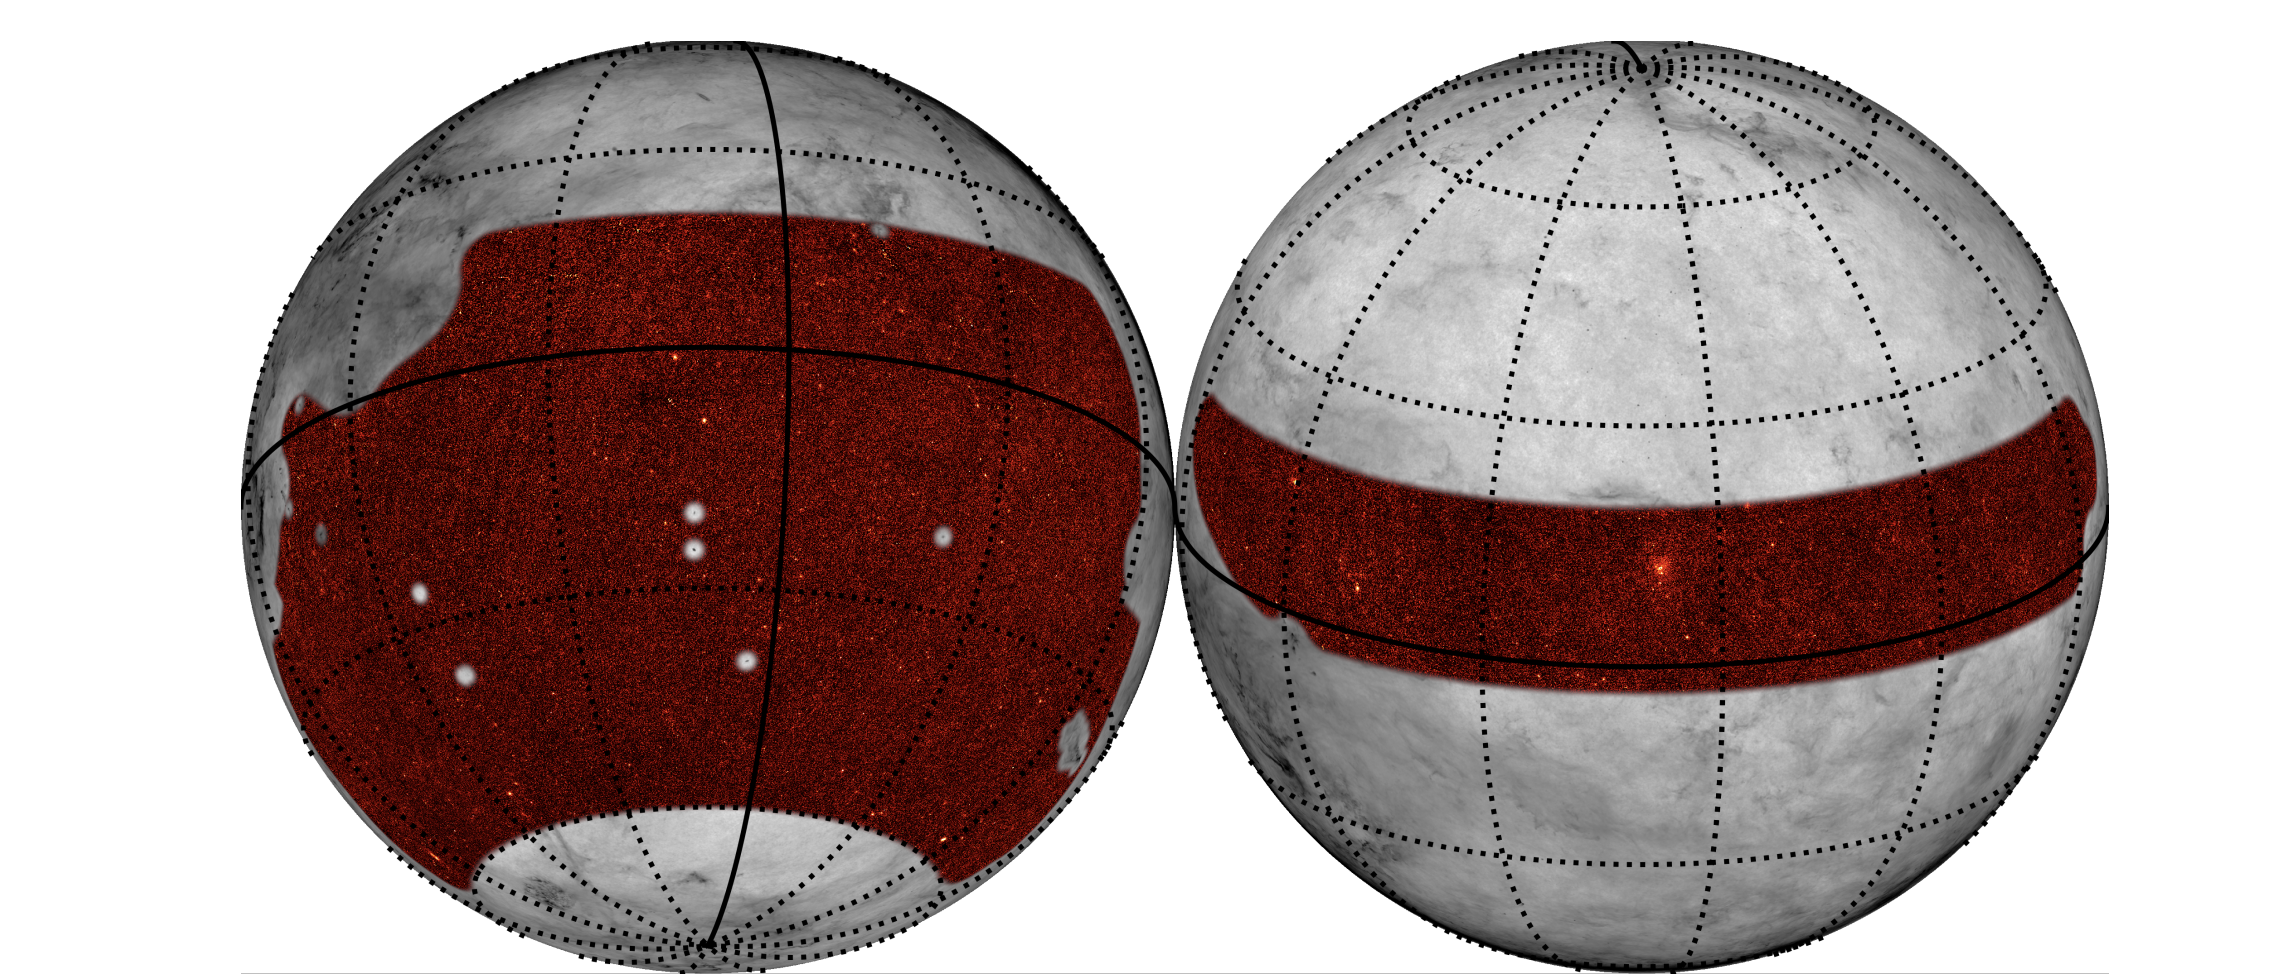

**Download ACT DR6 maps**

First, we will download and inspect necessary data products: the Compton-$y$ maps from ACT DR6 and DES map, along with their masks.  
Let's start by downloading the necessary maps with the wget command. We will analyze them with `pixell`.

In [ ]:
%%capture
#ACT DR6
!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/beam_ILC.txt
!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/downgraded10_ilc_SZ_yy.fits
#!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1//ilc_SZ_yy.fits #full map
!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/downgraded10_ilc_SZ_deproj_cib_1.2_24.0_yy.fits
!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/downgraded10_ilc_SZ_deproj_cib_1.4_10.7_yy.fits
!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/downgraded10_outputMask_wide_mask_GAL070_apod_1.50_deg_wExtended.fits #full mask
# !wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/wide_mask_GAL080_apod_1.50_deg_wExtended.fits

#DES
!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/downgraded10_DES_kappa4_in_car_interp_full.fits
!wget https://phy-act1.princeton.edu/public/data/dr6_ilc_v1/downgraded10_DES_unpodized_mask_in_car_interp.fits

All maps presented in this notebook were downgraded for computational purposes.  The downgrading operation was performed with the [`pixell.enmap.downgrade()`](https://pixell.readthedocs.io/en/latest/reference.html#pixell.enmap.downgrade) pixell function with a downgrading factor of 10. You can download full versions of the maps from [LAMBDA](https://lambda.gsfc.nasa.gov/product/act/actadv_dr6_compton_maps_get.html).

In [ ]:
# Load the default ACT DR6 Compton-y map, downgraded 10 times
ymap = enmap.read_map("downgraded10_ilc_SZ_yy.fits") #downgraded map
ymap.shape

In [ ]:
# Alternatively, it's possible to load the full map, and downgrade it
# ymap_full = enmap.read_map("ilc_SZ_yy.fits") #full map
# ymap = enmap.downgrade(ymap_full,10)

In [ ]:
# Similarly, load the downgraded DR6 mask
ymask = enmap.read_map("downgraded10_outputMask_wide_mask_GAL070_apod_1.50_deg_wExtended.fits")

# Also, load the DR6 beam (1.6 arcmin)
ell_beam, beam = np.loadtxt("beam_ILC.txt").T


In [ ]:
# Show the map
eshow(ymask*ymap, **{"downgrade": 4, "colorbar":True, "ticks":30})



Below we load the DES-Y3 weak lensing map, downloaded from [here](https://des.ncsa.illinois.edu/releases/y3a2/Y3massmaps). We chose the "KS" reconstruction method for the tomographic galaxy redshift bin 4. The map was first reprojected from the `Healpix` format to `CAR` with the [`pixell.reproject.healpix2map()`](https://pixell.readthedocs.io/en/latest/reference.html#pixell.reproject.healpix2map) function, and then downgraded.

In [ ]:
# Load the DES map
des_map = enmap.read_map("downgraded10_DES_kappa4_in_car_interp_full.fits")

# Load the DES mask
des_mask = enmap.read_map("downgraded10_DES_unpodized_mask_in_car_interp.fits")


In [ ]:
# Combine the two masks
mask = ymask*des_mask

In [ ]:
# Show the map
eshow(mask*des_map, **{"downgrade": 4, "colorbar":True, "ticks":30})

**Namaster**

To compute the cross-power spectra between the DR6 Compton-$y$ maps and DES data, we will use the [`pymaster`](https://namaster.readthedocs.io/en/latest/index.html) code (python implementation of `NaMaster`). We will follow the simple pseudo-Cl example, as shown [here](https://namaster.readthedocs.io/en/latest/sample_simple.html).



Let's start by defining the Namaster's field for the two maps that we want to correlate.

In [ ]:
# Define Namaster fields for each map
f_y = nmt.NmtField(mask, [ymap], beam = beam, wcs=ymap.wcs, n_iter=0) # deconvolve the beam in the DR6 ymap
f_des = nmt.NmtField(mask, [des_map], wcs=des_map.wcs, n_iter=0) #kappa map has no beam

Now let's define the binning for our cross-correlation, i.e., the central values for each bin.

In [ ]:
# In our case, we will start from specific ellmin--use the nmt.NmtBin.from_edge() function
ellmin = 30  # start from ell=30 (fsky~0.10)
ellmax = 1630
binwidth= 200

# Start by defining the edges of each bin
ell_ini = np.arange(ellmin+1, ellmax+1, binwidth)
ell_end = np.arange(ellmin+binwidth, ellmax+binwidth, binwidth)
print(ell_ini)
print(ell_end)

# Initialize Namaster binning and get the central ells
bins=nmt.NmtBin.from_edges(ell_ini=ell_ini, ell_end=ell_end, is_Dell=True) #request the Namaster output as D_ell=ell*(ell+1)*C_ell/2pi
ell_nmt= bins.get_effective_ells()
print("Namaster bins centers:", ell_nmt)

Now we are ready to compute the cross-correlation. This can be done with nmt.compute_full_master function. This computation takes about 1 minute, alternatively you can load precomputed values.

In [ ]:
# Compute the power spectra with Namaster -- this might take a while!
dl_ykappa = nmt.compute_full_master(f_y, f_des, bins)

In [ ]:
# Precomputed dl_ykappa values -- load them instead if you don't want to wait for the previous cell to run
#dl_ykappa = np.array([[4.04671392e-10, 1.05115566e-09, 1.19114070e-09, 1.67113102e-09, 1.67523508e-09, 8.88345961e-10, 2.14709824e-09, 2.65362992e-09]])


Plot the cross-correlation between the DR6 Compton-$y$ map and DES kappa map. It is of course lacking errorbars but we can get a sense of how the signal looks like.

It is worth remembering that the instrumental noise in the two maps is completely independent, so the increase in cross-correlation signal means that the computation is picking up on correlated small-scale signal in the y and kappa map, e.g. from galaxy clusters that induce both a y and lensing signal.


In [ ]:
# Plot the results
plt.subplots(figsize=(4, 3), dpi=150)
plt.plot(ell_nmt, dl_ykappa[0], "-o")
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$D_\ell^{y \kappa}$', fontsize=20)
plt.legend(loc='lower right', ncol=2, labelspacing=0.1)
plt.grid()
plt.show()

**DR6 Compton-$y$ map with CIB deprojected**

The DR6 map we investigated so far was constructed with the Needlet Internal Linear Combination (NILC) method, which preserves the Compton-$y$ signal but does not ensure this map is free of foregrounds.
One of the most important contaminants is the Cosmic Infrared Background (CIB)--thermal emission sourcing from star-forming galaxies, that peaks around redshift z=2. If CIB is present in the Compton-$y$ map, it can correlate with the LSS, and bias our intended y x LSS measurement.

Let's consider the standard method to mitigate the effect of the CIB, i.e., the CIB deprojections during the NILC procedure.

**CIB**

The CIB intensity can be written as the product of the frequency-dependent SED part and the template of the CIB anisotropies

 $ I^{\rm CIB}_{\nu} ( \hat{n} ) = \Theta^{\rm CIB}_{\nu} A^{\rm CIB} (\hat{n})$,


 where for the model for the CIB SED, $\Theta^{\rm CIB}_{\nu}$, one usually considers the modified blackbody (MBB) model, which is written down as

 $\Theta^{\rm CIB}_{\nu} =  \nu^\beta B_{\nu} (T_{\rm CIB} ) =   \nu^\beta \frac{2h\nu^3}{c^2} \frac{1}{e^\frac{hv}{k_B T_{\rm CIB}}-1} $,

where $B_{\nu} (T)$ is the Planck function, and $\beta_{\rm CIB}$ and $T_{\rm CIB}$ are two free CIB SED parameters, the spectral index and the temperature of the CIB, respectively.


CIB can be deprojected (=removed) during construction of the Compton-$y$ map,assuming some SED for the CIB field, e.g., the MBB. However, it is known that MBB is not the exact model for CIB SED, and the parameters $\beta_{\rm CIB}$ and $T_{\rm CIB}$ are poorly constrained.

Below we investigate how deprojecting CIB in the Compton-$y$ can affect the final cross-correlation with LSS.  Let's start by loading two CIB-deprojected DR6 y maps, which assume different values for the MBB parameters.  


In [ ]:
# Load the CIB-deprojected maps, also downgraded 10 times

# beta_CIB=1.4, T_CIB=10.7K
ymap_cib = enmap.read_map("downgraded10_ilc_SZ_deproj_cib_1.4_10.7_yy.fits")
# beta_CIB=1.2, T_CIB=24K
ymap_cib2 = enmap.read_map("downgraded10_ilc_SZ_deproj_cib_1.2_24.0_yy.fits")

> **Exercise:** Compute the power spectra with `pymaster` for the two DR6 $y$-maps we loaded above.  

In [ ]:
# your code goes here







Plot the results, along with the no CIB deprojection one we computed above. Again, we don't have errorbars yet, but we can already see how deprojecting CIB can affect the cross-correlation.

> Question: What do you notice about the cross-correlations with the $y$-maps with CIB deprojections?

In [ ]:
plt.subplots(figsize=(4, 3), dpi=150)
plt.plot(ell_nmt, dl_ykappa[0], "-o", color="blue", label='no CIB deproj.')
# plt.plot(ell_nmt, (dl_cib[0]), "-o", color="orange",label=r'deproj. CIB ($\beta_\mathrm{CIB}=1.4, T_\mathrm{CIB}=10.7$K)')
# plt.plot(ell_nmt, (dl_cib2[0]), "-o", color="green", label=r'deproj. CIB 2 ($\beta_\mathrm{CIB}=1.2, T_\mathrm{CIB}=24.0$K)')
plt.xlabel('$\ell$', fontsize=20)
plt.ylabel('$D_\ell^{y \kappa}$', fontsize=20)
# plt.legend(loc='lower right', ncol=2, labelspacing=0.1)
plt.legend(loc='upper left', fontsize=8)
plt.grid()
plt.show()

**Add Namaster Errorbars**

There is different noise in every CIB-deprojected map. To quantify how much of the difference is due to these noise fluctuations versus due to differences in the amount of deprojected signal, let's add the errorbars.
We will do this by computing the Gaussian estimate of the covariance with `Namaster`, as shown in this [example](https://namaster.readthedocs.io/en/latest/sample_covariance.html).

This is the longest computation in the notebook and will take around 5 minutes per cross-correlation. If you don't want to wait, you can scroll to the last cell before the plot, and simply load precomputed errorbar values.

To compute the Namaster covariance, we need estimates of the auto- and cross-power spectra between our maps defined at every ell to pass to the nmt.gaussian_covariance() object. The Namaster example uses precomputed theory predictions. To make things easier, we will compute the power spectra and interpolate.

In [ ]:
# First, define a function that computes Namaster power spectra between two fields, and interpolates the value at every ell.
from scipy import interpolate
def interpolate_cl(field1, field2, nmt_bin_width, ell_interpol_max):
    # Define new binning (has to be in C_ell)
    b = nmt.NmtBin.from_lmax_linear(ell_interpol_max+100, nmt_bin_width, is_Dell=False)
    ell= b.get_effective_ells()

    # #Compute new Cl's cl_inter to interpolate
    cl = nmt.compute_full_master(field1, field2, b)

    #set cl(ell=1) to zero to avoid extrapolation
    cl2 = np.insert(cl,[0,0],[0,0] )
    ell2 = np.insert(ell,[0,0],[0,1])

    #interpolate
    ell_new=np.arange(0., ell_interpol_max, 1) #up to ell_interp_max
    f=interpolate.interp1d(ell2, cl2)
    cl_interpolate=f(ell_new)

    return cl_interpolate, ell_new


In [ ]:
interp_bin_width =10
ELLMAX = 1700 #interpolate to larger ellmax than the measured cross-correlation

cl_12, ell_inter = interpolate_cl(f_y, f_des, nmt_bin_width=interp_bin_width, ell_interpol_max=ELLMAX)
cl_11, ell_inter = interpolate_cl(f_y, f_y, nmt_bin_width=interp_bin_width, ell_interpol_max=ELLMAX)
cl_22, ell_inter = interpolate_cl(f_des, f_des, nmt_bin_width=interp_bin_width, ell_interpol_max=ELLMAX)
cl_21, ell_inter =  cl_12, ell_inter  #same as cl_12


Now we are ready to compute the Namaster covariance.

This is the longest computation in this notebook, and will take about 5 minutes.

In [ ]:
# Workspace
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f_y, f_des, bins)

# Gaussian estimate of the covariance
cw = nmt.NmtCovarianceWorkspace()
cw.compute_coupling_coefficients(f_y, f_des, f_y, f_des, lmax=ELLMAX-1) # lmax needs to be < len(cl1_interpolate)

# Compute the covariance
n_bins=len(ell_nmt) # number of bins
covar = nmt.gaussian_covariance(cw, 0, 0, 0, 0, [cl_11],[cl_12],[cl_21], [cl_22], w, wb=w).reshape([n_bins, 1,n_bins, 1])
covariance = covar[:, 0, :, 0]

# Get the errorbars
sigma=np.sqrt(covariance.diagonal())

> Let's do the same for the cross-correlation with the y map that deprojects the CIB with $\beta_{\rm CIB}$=1.4 and $T_{\rm CIB}$=10.7K.

In [ ]:
# Compute the errorbars for the y x g with the CIB-deprojected y-map

# Interpolate
# cl_12_cib, ell_inter =
# cl_11_cib, ell_inter =
# cl_22_cib, ell_inter =  cl_22, ell_inter
# cl_21_cib, ell_inter =  cl_12_cib, ell_inter  #same as cl_12

# your code goes here

> **Exercise** Now, let's plot the two cross-correlations with Namaster errorbars. What do you notice?

In [ ]:
plt.subplots(figsize=(4, 3), dpi=150)
plt.errorbar(ell_nmt, dl_ykappa[0], sigma,  fmt ="o-", color="blue", label='no CIB deproj.')
# plt.errorbar(ell_nmt+20, (dl_cib[0]), sigma_cib,  fmt ="o-", color="orange", label=r'deproj. CIB ($\beta_\mathrm{CIB}=1.4, T_\mathrm{CIB}=10.7$K)') #artifically offset the points for visual purposes
plt.xlabel('$\ell$', fontsize=20)
plt.ylabel('$D_\ell^{y \kappa}$', fontsize=20)

plt.legend(loc='upper left', ncol=1, labelspacing=0.1, fontsize=9)
plt.grid()
plt.show()

This is just an illustration of how removing the CIB can affect the cross power spectrum with LSS! Deprojecting CIB with different values of $\beta_{\rm CIB}$ and $T_{\rm CIB}$ can yield very different results. In this case the change is not dramatic, though it is visible by eye. For other LSS samples the effect can be larger/smaller. Finding the correct values of $\beta_{\rm CIB}$ and $T_{\rm CIB}$ that characterize the CIB field for a given sample might be a significant challenge.

Sometimes the simple deprojection might not be enough to mitigate the effect of the CIB contamination. In that case, we recommend using the first-moment deprojected maps, which deproject not only the CIB, but also the first-moment of the Taylor expansion of the SED with respect to either $\beta_{\rm CIB}$ or $T_{\rm CIB}$, as discussed in Coulton et al.  We find that these maps are generally stable to the exact choice of the CIB parameters.

It is important to note that the CIB is just one of the contaminants that can be present in the Compton-$y$ map, which can correlate with LSS, and bias the final measurement. Other examples include non-masked radio sources, the ISW effect, or CO lines.  